# Source-Only Baseline — v3 (3 complete datasets)

**Goal:** merge the 3 complete v2 datasets (with the GUS counterfactuals) and repeat the source-only baseline + LOSO analysis.

**Datasets:**

| Source | Biased | Neutral | Total |
|-------|--------|---------|-------|
| `biased_corpus_v2` | 2 477 | 1 131 | 3 608 |
| `gemini_only_v2` | 696 | 2 317 | 3 013 |
| `gus_only_v2` | 1 371 | 1 442 | 2 813 |
| **Total** | **4 544** | **4 890** | **9 434** |

**Difference vs v2 (7320):** v2 used the original GUS (707 entries, no counterfactuals). v3 uses the full `gus_only_v2` (2813 entries, with 808 counterfactual pairs).

In [1]:
import json, os
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load and merge the 3 datasets

In [2]:
root_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
v2_dir = os.path.join(root_dir, "dataset", "v2")

# Load the 3 CSVs
bc = pd.read_csv(os.path.join(v2_dir, "biased_corpus_v2.csv"))
gm = pd.read_csv(os.path.join(v2_dir, "gemini_only_v2.csv"))
gs = pd.read_csv(os.path.join(v2_dir, "gus_only_v2.csv"))

print(f"biased_corpus_v2: {len(bc)} entries")
print(f"gemini_only_v2:   {len(gm)} entries")
print(f"gus_only_v2:      {len(gs)} entries")
print(f"Total:            {len(bc)+len(gm)+len(gs)} entries\n")

# Merge everything
df = pd.concat([bc, gm, gs], ignore_index=True)
df["label"] = df["hasbias"].astype(int)

# Canonical source names (for consistency with v2)
SOURCE_CANONICAL = {
    "biased_corpus_only": "biased-corpus",
    "biased_corpus_v2": "biased-corpus",
    "gemini_only": "gemini",
    "gemini_only_v2": "gemini",
    "gus_only": "gus-dataset",
    "gus_only_v2": "gus-dataset",
}
df["source_eval"] = df["source"].map(SOURCE_CANONICAL).fillna(df["source"])

print(f"Dataset v3 merged: {len(df)} entries")
print(f"Unique texts: {df['text'].nunique()}")
print(f"Duplicate texts: {len(df) - df['text'].nunique()}\n")

ct = pd.crosstab(df["source_eval"], df["label"], margins=True)
ct.columns = ["neutral", "biased", "total"]
ct.index.name = "source"
ct

biased_corpus_v2: 3608 entries
gemini_only_v2:   3013 entries
gus_only_v2:      2813 entries
Total:            9434 entries

Dataset v3 merged: 9434 entries
Unique texts: 9394
Duplicate texts: 40



,neutral,biased,total
source,,,
biased-corpus,1131,2477,3608
gemini,2317,696,3013
gus-dataset,1442,1371,2813
All,4890,4544,9434


In [3]:
# Detail by role (original, counterfactual, unpaired)
print("Distribution by role and source:\n")
ct_role = pd.crosstab(df["source_eval"], df["role"], margins=True)
print(ct_role)
print()

# Biased ratio by source
print("Biased ratio by source:")
for src in sorted(df["source_eval"].unique()):
    sub = df[df["source_eval"] == src]
    ratio = sub["label"].mean()
    print(f"  {src:20s}  {ratio:.1%} biased  ({sub['label'].sum()}/{len(sub)})")

Distribution by role and source:

role           counterfactual  original  unpaired   All
source_eval                                            
biased-corpus            1131      1131      1346  3608
gemini                    696       696      1621  3013
gus-dataset               808       808      1197  2813
All                      2635      2635      4164  9434

Biased ratio by source:
  biased-corpus         68.7% biased  (2477/3608)
  gemini                23.1% biased  (696/3013)
  gus-dataset           48.7% biased  (1371/2813)


## 2. Source-only baseline (deterministic rules)

For each source, predict the majority class.

In [4]:
source_majority = (
    df.groupby("source_eval")["label"]
    .mean()
    .apply(lambda x: int(x >= 0.5))
    .to_dict()
)

df["pred"] = df["source_eval"].map(source_majority)
y_true = df["label"]
y_pred = df["pred"]

acc = accuracy_score(y_true, y_pred)
baseline_f1 = f1_score(y_true, y_pred)

print("=== BASELINE SOURCE-ONLY (v3 — 3 complete datasets) ===\n")
print("Rules learned per source:")
for src, rule in sorted(source_majority.items()):
    print(f"  {src:20s} -> {'biased' if rule else 'neutral'}")
print()
print(f"Accuracy: {acc*100:.2f}%\n")
print(classification_report(y_true, y_pred, target_names=["neutral", "biased"]))

=== BASELINE SOURCE-ONLY (v3 — 3 complete datasets) ===

Rules learned per source:
  biased-corpus        -> biased
  gemini               -> neutral
  gus-dataset          -> neutral

Accuracy: 66.10%

              precision    recall  f1-score   support

     neutral       0.65      0.77      0.70      4890
      biased       0.69      0.55      0.61      4544

    accuracy                           0.66      9434
   macro avg       0.67      0.66      0.65      9434
weighted avg       0.67      0.66      0.66      9434



## 3. Confusion matrix

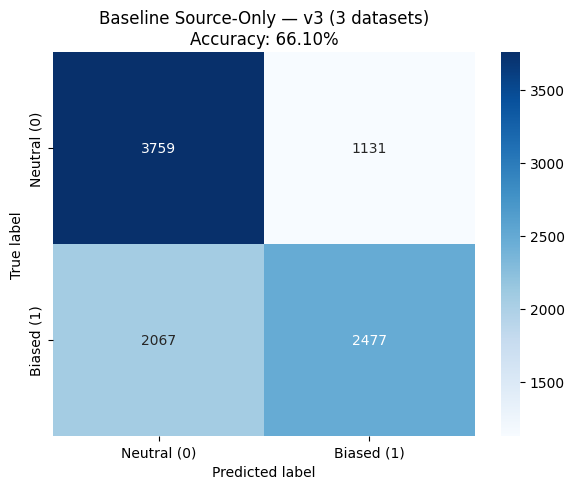


Detail by source:
  biased-corpus         rule ->  biased  correct=2477/3608  (68.7%)
  gemini                rule -> neutral  correct=2317/3013  (76.9%)
  gus-dataset           rule -> neutral  correct=1442/2813  (51.3%)


In [5]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Neutral (0)", "Biased (1)"],
            yticklabels=["Neutral (0)", "Biased (1)"], ax=ax)
ax.set_title(f"Baseline Source-Only — v3 (3 datasets)\nAccuracy: {acc*100:.2f}%")
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.show()

print("\nDetail by source:")
for src, rule in sorted(source_majority.items()):
    sub = df[df["source_eval"] == src]
    correct = (sub["label"] == rule).sum()
    total = len(sub)
    lbl = "biased" if rule else "neutral"
    print(f"  {src:20s}  rule -> {lbl:>7s}  correct={correct}/{total}  ({correct/total*100:.1f}%)")

## 4. Comparison: v2 (7320) vs v3 (9434)

In v2 the source-only baseline reached **71.00%** because:
- `biased-corpus` (3600) -> biased (68% biased)
- `gemini` (3013) -> neutral (77% neutral)
- `gus-dataset-v1` (707) -> neutral (61% neutral)

In v3, `gus-dataset` goes from 707 to 2813 entries (with counterfactuals), and the biased/neutral distribution is more balanced.

In [6]:
# v2 results (copied from the previous notebook)
v2_acc = 0.7100
v2_f1 = 0.70  # approximate from v2 notebook

comparison = pd.DataFrame({
    "Dataset": ["v2 (7320)", "v3 (" + str(len(df)) + ")"],
    "Accuracy": [f"{v2_acc*100:.2f}%", f"{acc*100:.2f}%"],
    "F1 (biased)": [f"{v2_f1:.4f}", f"{baseline_f1:.4f}"],
})

print("=== SOURCE-ONLY BASELINE COMPARISON: v2 vs v3 ===\n")
print(comparison.to_string(index=False))
print()

diff = acc - v2_acc
if diff < 0:
    print(f"The source-only baseline DROPPED {abs(diff)*100:.2f} pp in v3.")
    print("This indicates LESS source confounding — the sources are more balanced.")
else:
    print(f"The source-only baseline ROSE {diff*100:.2f} pp in v3.")

=== SOURCE-ONLY BASELINE COMPARISON: v2 vs v3 ===

  Dataset Accuracy F1 (biased)
v2 (7320)   71.00%      0.7000
v3 (9434)   66.10%      0.6077

The source-only baseline DROPPED 4.90 pp in v3.
This indicates LESS source confounding — the sources are more balanced.


## 5. Leave-One-Source-Out (LOSO) — Baseline

For each source, we train on the rest and test on the held-out source.
The baseline predicts the global majority class of the training set.

In [7]:
sources_arr = df["source_eval"].values
y_arr = df["label"].values

results_loso = []

for test_source in sorted(np.unique(sources_arr)):
    test_mask = sources_arr == test_source
    train_mask = ~test_mask

    y_train = y_arr[train_mask]
    y_test = y_arr[test_mask]
    n_test = test_mask.sum()

    # Source-only baseline: predict the global training majority
    majority = int(y_train.mean() >= 0.5)
    y_pred_bl = np.full(n_test, majority)
    acc_bl = accuracy_score(y_test, y_pred_bl)
    f1_bl = f1_score(y_test, y_pred_bl, zero_division=0)
    cm_bl = confusion_matrix(y_test, y_pred_bl, labels=[0, 1])

    biased_test = y_test.sum()
    neutral_test = n_test - biased_test
    print(f"\n--- Test: {test_source} ({n_test}: {biased_test} biased, {neutral_test} neutral) ---")
    print(f"  Train majority: {'biased' if majority else 'neutral'} ({y_train.mean():.1%} biased)")
    print(f"  Baseline Acc={acc_bl:.4f}  F1={f1_bl:.4f}")

    results_loso.append({
        "test_source": test_source, "n_test": n_test,
        "biased": biased_test, "neutral": neutral_test,
        "baseline_acc": acc_bl, "baseline_f1": f1_bl, "cm_baseline": cm_bl,
    })

loso_df = pd.DataFrame(results_loso)
print("\n\n=== LOSO BASELINE SUMMARY (v3) ===")
print(loso_df[["test_source", "n_test", "biased", "neutral",
               "baseline_acc", "baseline_f1"]].to_string(index=False))


--- Test: biased-corpus (3608: 2477 biased, 1131 neutral) ---
  Train majority: neutral (35.5% biased)
  Baseline Acc=0.3135  F1=0.0000

--- Test: gemini (3013: 696 biased, 2317 neutral) ---
  Train majority: biased (59.9% biased)
  Baseline Acc=0.2310  F1=0.3753

--- Test: gus-dataset (2813: 1371 biased, 1442 neutral) ---
  Train majority: neutral (47.9% biased)
  Baseline Acc=0.5126  F1=0.0000


=== LOSO BASELINE SUMMARY (v3) ===
  test_source  n_test  biased  neutral  baseline_acc  baseline_f1
biased-corpus    3608    2477     1131      0.313470     0.000000
       gemini    3013     696     2317      0.230999     0.375303
  gus-dataset    2813    1371     1442      0.512620     0.000000


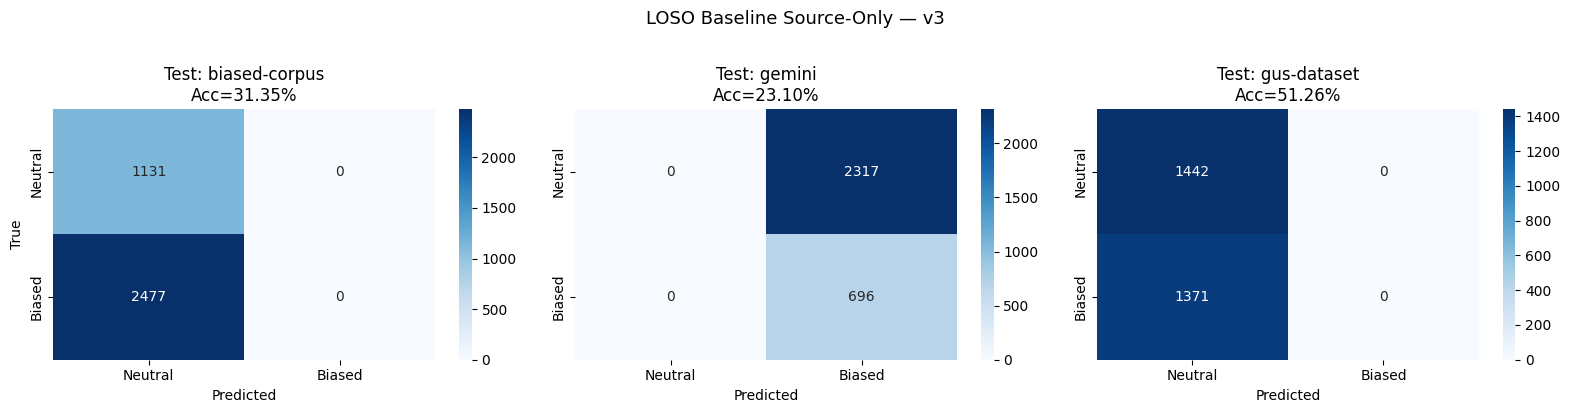

In [8]:
# Confusion matrices LOSO baseline
labels = ["Neutral", "Biased"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, row in enumerate(results_loso):
    sns.heatmap(row["cm_baseline"], annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=axes[i])
    axes[i].set_title(f"Test: {row['test_source']}\nAcc={row['baseline_acc']:.2%}")
    axes[i].set_ylabel("True" if i == 0 else "")
    axes[i].set_xlabel("Predicted")
fig.suptitle("LOSO Baseline Source-Only — v3", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. LOSO comparison: v2 vs v3

v2 LOSO baseline results (7320):

| test_source | n_test | baseline_acc | baseline_f1 |
|-------------|--------|-------------|-------------|
| biased-corpus | 3600 | 0.3200 | 0.0000 |
| gemini | 3013 | 0.2310 | 0.3753 |
| gus-dataset-v1 | 707 | 0.6110 | 0.0000 |

In [9]:
# v2 results (from the previous notebook)
v2_loso = {
    "biased-corpus": {"n_test": 3600, "baseline_acc": 0.3200, "baseline_f1": 0.0000},
    "gemini":        {"n_test": 3013, "baseline_acc": 0.2310, "baseline_f1": 0.3753},
    "gus-dataset":   {"n_test":  707, "baseline_acc": 0.6110, "baseline_f1": 0.0000},
}

rows = []
for row in results_loso:
    src = row["test_source"]
    # Match v2 key (gus-dataset-v1 -> gus-dataset)
    v2_key = src if src in v2_loso else src.replace("-v1", "")
    v2 = v2_loso.get(v2_key, {})
    rows.append({
        "test_source": src,
        "n_v2": v2.get("n_test", "—"),
        "n_v3": row["n_test"],
        "Acc v2": f"{v2.get('baseline_acc', 0):.2%}" if v2 else "—",
        "Acc v3": f"{row['baseline_acc']:.2%}",
        "F1 v2": f"{v2.get('baseline_f1', 0):.4f}" if v2 else "—",
        "F1 v3": f"{row['baseline_f1']:.4f}",
    })

comp_df = pd.DataFrame(rows)
print("=== LOSO BASELINE COMPARISON: v2 vs v3 ===\n")
print(comp_df.to_string(index=False))
print()

avg_v3 = np.mean([r["baseline_acc"] for r in results_loso])
avg_v2 = np.mean([v["baseline_acc"] for v in v2_loso.values()])
print(f"Mean baseline Acc v2: {avg_v2:.2%}")
print(f"Mean baseline Acc v3: {avg_v3:.2%}")
print(f"Mean delta: {avg_v3 - avg_v2:+.2%}")

=== LOSO BASELINE COMPARISON: v2 vs v3 ===

  test_source  n_v2  n_v3 Acc v2 Acc v3  F1 v2  F1 v3
biased-corpus  3600  3608 32.00% 31.35% 0.0000 0.0000
       gemini  3013  3013 23.10% 23.10% 0.3753 0.3753
  gus-dataset   707  2813 61.10% 51.26% 0.0000 0.0000

Mean baseline Acc v2: 38.73%
Mean baseline Acc v3: 35.24%
Mean delta: -3.50%


## 7. Balance analysis by source

We compare the degree of "purity" of each source (the closer to 50/50, the less confounding).

In [10]:
balance = []
for src in sorted(df["source_eval"].unique()):
    sub = df[df["source_eval"] == src]
    ratio = sub["label"].mean()
    purity = max(ratio, 1 - ratio)  # 0.5 = perfectly balanced, 1.0 = fully pure
    balance.append({
        "source": src,
        "total": len(sub),
        "biased": sub["label"].sum(),
        "neutral": len(sub) - sub["label"].sum(),
        "ratio_biased": f"{ratio:.1%}",
        "purity": f"{purity:.1%}",
    })

bal_df = pd.DataFrame(balance)
print("=== BALANCE BY SOURCE (v3) ===\n")
print(bal_df.to_string(index=False))
print()

# Compare with v2
print("Purity comparison (max(ratio, 1-ratio)):")
print("  v2: biased-corpus=68% biased -> purity 68%")
print("       gemini=77% neutral -> purity 77%")
print("       gus-dataset-v1=61% neutral -> purity 61%")
print()
for b in balance:
    print(f"  v3: {b['source']:20s} purity={b['purity']}")

=== BALANCE BY SOURCE (v3) ===

       source  total  biased  neutral ratio_biased purity
biased-corpus   3608    2477     1131        68.7%  68.7%
       gemini   3013     696     2317        23.1%  76.9%
  gus-dataset   2813    1371     1442        48.7%  51.3%

Purity comparison (max(ratio, 1-ratio)):
  v2: biased-corpus=68% biased -> purity 68%
       gemini=77% neutral -> purity 77%
       gus-dataset-v1=61% neutral -> purity 61%

  v3: biased-corpus        purity=68.7%
  v3: gemini               purity=76.9%
  v3: gus-dataset          purity=51.3%


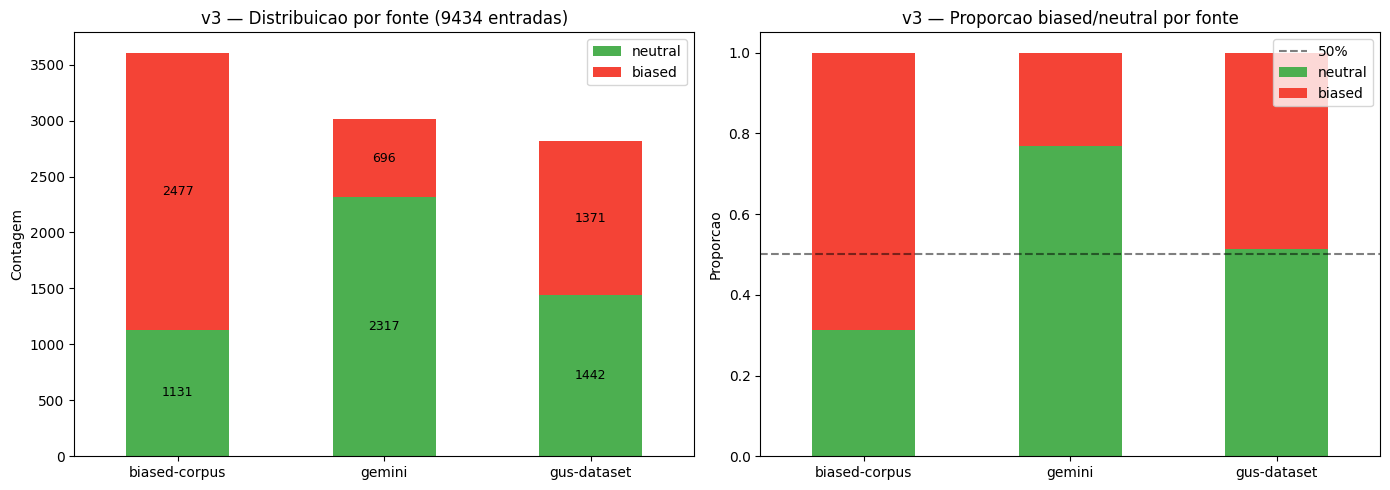

In [11]:
# Bar chart: biased/neutral distribution by source
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# v3
ct_plot = pd.crosstab(df["source_eval"], df["label"])
ct_plot.columns = ["neutral", "biased"]
ct_plot.plot(kind="bar", stacked=True, ax=axes[0], color=["#4CAF50", "#F44336"])
axes[0].set_title(f"v3 — Distribution by source ({len(df)} entries)")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, label_type="center", fontsize=9)

# Ratio
ct_norm = ct_plot.div(ct_plot.sum(axis=1), axis=0)
ct_norm.plot(kind="bar", stacked=True, ax=axes[1], color=["#4CAF50", "#F44336"])
axes[1].set_title("v3 — Biased/neutral ratio by source")
axes[1].set_ylabel("Ratio")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].axhline(y=0.5, color="black", linestyle="--", alpha=0.5, label="50%")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Deduplication and impact

Check whether there are duplicate texts across sources and how they affect the counts.

In [12]:
# Duplicates within each source
print("Duplicate texts within each source:")
for src in sorted(df["source_eval"].unique()):
    sub = df[df["source_eval"] == src]
    dups = len(sub) - sub["text"].nunique()
    print(f"  {src:20s}  {dups} duplicates  ({len(sub)} total, {sub['text'].nunique()} unique)")

print()

# Duplicates across sources
text_sources = df.groupby("text")["source_eval"].nunique()
cross_source = text_sources[text_sources > 1]
print(f"Texts appearing in more than 1 source: {len(cross_source)}")
if len(cross_source) > 0:
    print("Examples:")
    for txt in cross_source.index[:5]:
        srcs = df[df["text"] == txt]["source_eval"].unique()
        print(f"  '{txt[:80]}...' -> {list(srcs)}")

print()

# Deduplicated dataset
df_dedup = df.drop_duplicates(subset=["text"])
print(f"Dataset after dedup by text: {len(df_dedup)} entries (removed {len(df)-len(df_dedup)})")
ct_dedup = pd.crosstab(df_dedup["source_eval"], df_dedup["label"], margins=True)
ct_dedup.columns = ["neutral", "biased", "total"]
ct_dedup.index.name = "source"
ct_dedup

Duplicate texts within each source:
  biased-corpus         8 duplicates  (3608 total, 3600 unique)
  gemini                0 duplicates  (3013 total, 3013 unique)
  gus-dataset           26 duplicates  (2813 total, 2787 unique)

Texts appearing in more than 1 source: 6
Examples:
  'Don't you think working class neighborhoods have higher crime rates because of t...' -> ['biased-corpus', 'gus-dataset']
  'I heard that many Hispanics commit crimes because of their heritage....' -> ['biased-corpus', 'gus-dataset']
  'People build businesses and run households....' -> ['biased-corpus', 'gus-dataset']
  'The mental capacity of these special souls might be limited, but their ability t...' -> ['biased-corpus', 'gus-dataset']
  'When will middle-age people realize their best days are behind them?...' -> ['biased-corpus', 'gus-dataset']

Dataset after dedup by text: 9394 entries (removed 40)


,neutral,biased,total
source,,,
biased-corpus,1124,2476,3600
gemini,2317,696,3013
gus-dataset,1433,1348,2781
All,4874,4520,9394


## 9. Export the merged v3 dataset (JSON)

Export for use in feature extraction pipelines.

In [13]:
# Build JSON in the format compatible with bias_sentences_v2.json
entries_v3 = []
for i, row in df.iterrows():
    entries_v3.append({
        "id": i + 1,
        "type": "single",
        "text": row["text"],
        "has_bias": bool(row["hasbias"]),
        "bias_type": row.get("topic", None),
        "bias_description": None,
        "source": row["source"],
        "role": row.get("role", None),
        "original_id": row.get("original_id", None),
        "pair_id": row.get("pair_id", None),
        "topic": row.get("topic", None),
        "sentence_id": row.get("sentence_id", None),
        "edit_spans": row.get("edit_spans", None),
    })

v3_json = {"entries": entries_v3}
out_path = os.path.join(v2_dir, "bias_sentences_v3.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(v3_json, f, ensure_ascii=False, indent=2)

print(f"Exported: {out_path}")
print(f"  Entries: {len(entries_v3)}")
print(f"  Biased: {sum(1 for e in entries_v3 if e['has_bias'])}")
print(f"  Neutral: {sum(1 for e in entries_v3 if not e['has_bias'])}")

Exported: c:\Users\user\Documents\GitHub\project\dataset\v2\bias_sentences_v3.json
  Entries: 9434
  Biased: 4544
  Neutral: 4890


## 10. Conclusion

Final comparative summary.

In [14]:
print("=" * 70)
print("SUMMARY: SOURCE-ONLY BASELINE")
print("=" * 70)
print()
print(f"v1 original (5500):  95.02% accuracy (severe confounding)")
print(f"v2 (7320):           71.00% accuracy (confounding partially mitigated)")
print(f"v3 ({len(df)}):          {acc*100:.2f}% accuracy")
print()

if acc < v2_acc:
    print(f"The source-only baseline DROPPED from {v2_acc*100:.2f}% (v2) para {acc*100:.2f}% (v3).")
    print("This means source confounding is decreasing — the sources")
    print("are more balanced and a trivial source->label mapping no longer")
    print("predicts as well.")
else:
    print(f"The source-only baseline ROSE from {v2_acc*100:.2f}% (v2) para {acc*100:.2f}% (v3).")
    print("Check the source distribution — there may be an imbalance.")

print()
print("Next step: extract BERT features for the v3 dataset and repeat")
print("the LOSO with XGBoost to compare against the baseline.")

SUMMARY: SOURCE-ONLY BASELINE

v1 original (5500):  95.02% accuracy (severe confounding)
v2 (7320):           71.00% accuracy (confounding partially mitigated)
v3 (9434):          66.10% accuracy

The source-only baseline DROPPED from 71.00% (v2) para 66.10% (v3).
This means source confounding is decreasing — the sources
are more balanced and a trivial source->label mapping no longer
predicts as well.

Next step: extract BERT features for the v3 dataset and repeat
the LOSO with XGBoost to compare against the baseline.
